# Unzip dataset

In [1]:
!unzip '/content/mango_leaf-8-class.zip'

Archive:  /content/mango_leaf-8-class.zip
   creating: mango_leaf/New folder/
   creating: mango_leaf/New folder/Anthracnose/
  inflating: mango_leaf/New folder/Anthracnose/20211008_124249 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124250 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124252 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124253 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124256 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124301 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124302 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124305 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124306 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124310 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124312 (Custom).jpg  
  inflating: man

# import library

In [2]:
import os
import shutil
import random

import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# Import Data Science Libraries
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import itertools
import random

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
import skimage
from skimage.transform import resize
# label binarizer
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Mobile Net

## Split data into main and test validation

In [3]:
from ast import main
# Define your dataset directories and the directories where you want to create the splits:

dataset_dir = "/content/mango_leaf/New folder"  # Replace with the path to your dataset
main_dir = "train_set"
test_dir = "test_set"

# Create the train, test, and validation directories if they don't exist
os.makedirs(main_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [4]:
# Set the split ratio (for main 80% , for test 20%)

main_ratio = 0.80
test_ratio = 0.20

In [5]:
# iterate throught the folders containing our two type of data and splite them into main and test

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)

    if os.path.isdir(class_path):
        file_list = os.listdir(class_path)
        random.shuffle(file_list)

        main_split = int(len(file_list) * main_ratio)
        test_split = int(len(file_list) * (main_ratio + test_ratio))

        main_files = file_list[:main_split]
        test_files = file_list[main_split:test_split]


        for file_name in main_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(main_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)

        for file_name in test_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(test_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)



## run

In [6]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 32
image_size = (224, 224)
epochs = 30

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


In [8]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 800 images belonging to 8 classes.


# mobilenetv2

In [9]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.050)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.3680 - loss: 564.5981 - val_accuracy: 0.3562 - val_loss: 1.6028
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.3301 - loss: 8.3284 - val_accuracy: 0.3703 - val_loss: 48.6943
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.3322 - loss: 15.5139 - val_accuracy: 0.3313 - val_loss: 2.0980
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.3225 - loss: 7.6791 - val_accuracy: 0.3469 - val_loss: 1.6922
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.2998 - loss: 3.7313 - val_accuracy: 0.4375 - val_loss: 2.7198
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.3177 - loss: 1.8262 - val_accuracy: 0.3453 - val_loss: 1.6670
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.3022 - loss: 8.0393 - val_accuracy: 0.3453 - val_loss: 1.6454
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step -

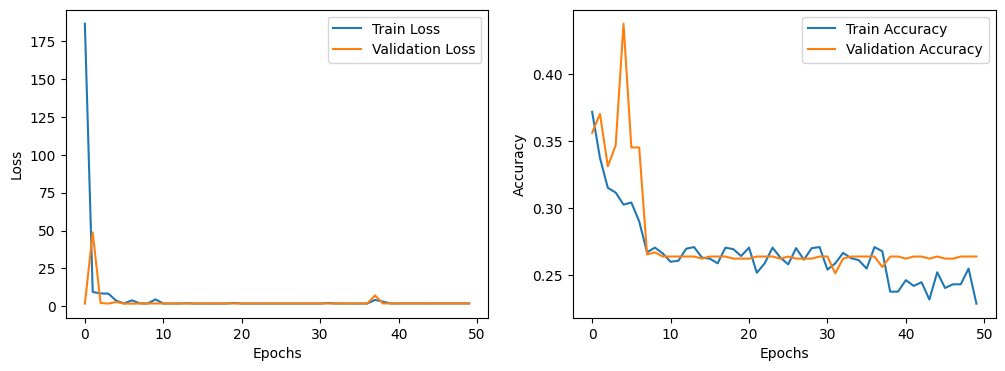

In [10]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       1.00      0.01      0.02       100
           2       0.99      1.00      1.00       100
           3       1.00      0.11      0.20       100
           4       1.00      0.05      0.10       100
           5       0.15      1.00      0.26       100
           6       0.00      0.00      0.00       100
           7       1.00      0.01      0.02       100

    accuracy                           0.27       800
   macro avg       0.64      0.27      0.20       800
weighted avg       0.64      0.27      0.20       800



In [12]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.2725


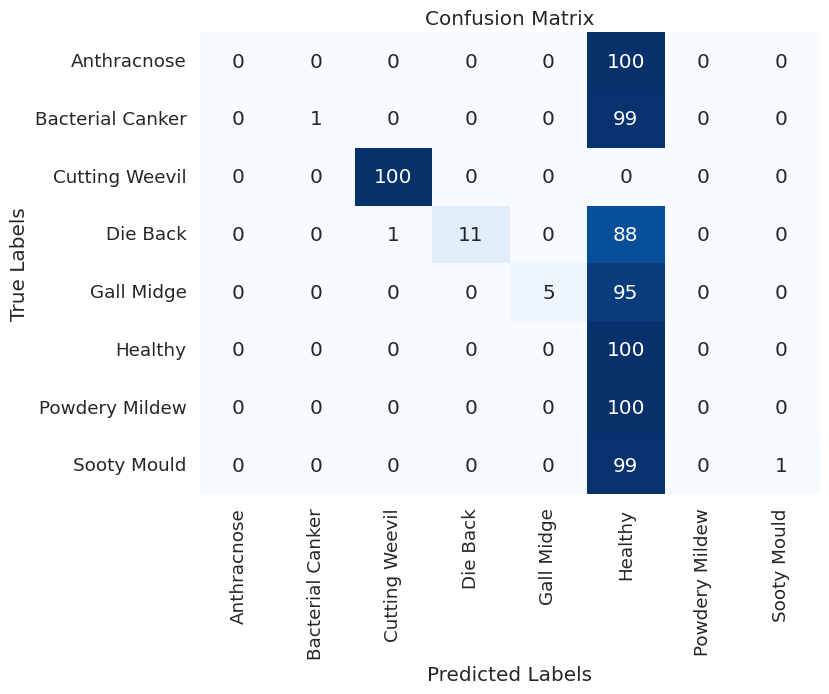

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


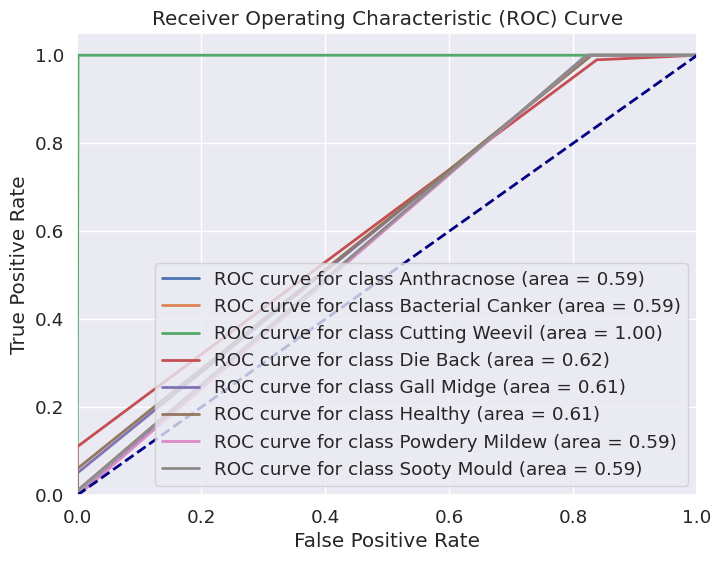

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_m1, predictions_m1[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
m1.save('model.h5')

# learning rate = 0.075

In [15]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.075)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.4076 - loss: 1226.9830 - val_accuracy: 0.4531 - val_loss: 2.2542
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.3718 - loss: 11.8657 - val_accuracy: 0.3766 - val_loss: 3.4559
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.3520 - loss: 22.6382 - val_accuracy: 0.4203 - val_loss: 1.6214
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.3424 - loss: 11.4433 - val_accuracy: 0.3781 - val_loss: 4.3342
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.3149 - loss: 12.5367 - val_accuracy: 0.3391 - val_loss: 1.8869
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.3117 - loss: 2.2330 - val_accuracy: 0.2906 - val_loss: 1.6263
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.2921 - loss: 2.5940 - val_accuracy: 0.2875 - val_loss: 1.6326
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.2802 - loss: 1.6604 - val_accuracy: 

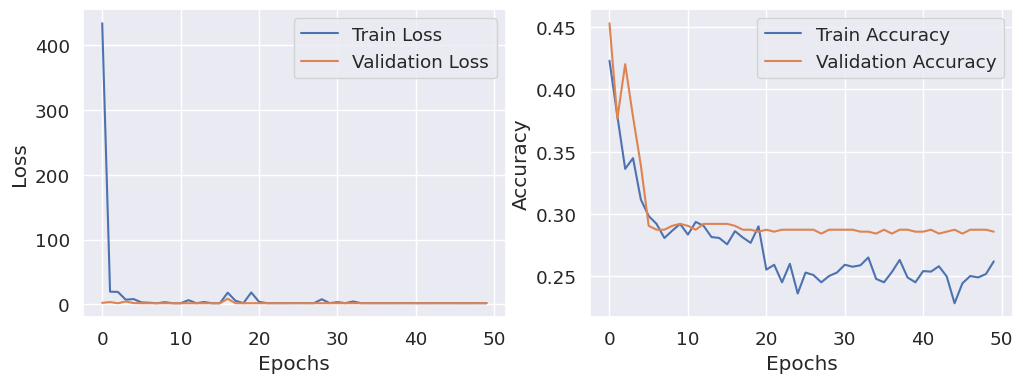

In [16]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.04       100
           1       1.00      0.04      0.08       100
           2       1.00      0.99      0.99       100
           3       1.00      0.01      0.02       100
           4       1.00      0.02      0.04       100
           5       0.15      1.00      0.26       100
           6       0.00      0.00      0.00       100
           7       1.00      0.29      0.45       100

    accuracy                           0.30       800
   macro avg       0.77      0.30      0.24       800
weighted avg       0.77      0.30      0.24       800



In [18]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.29625


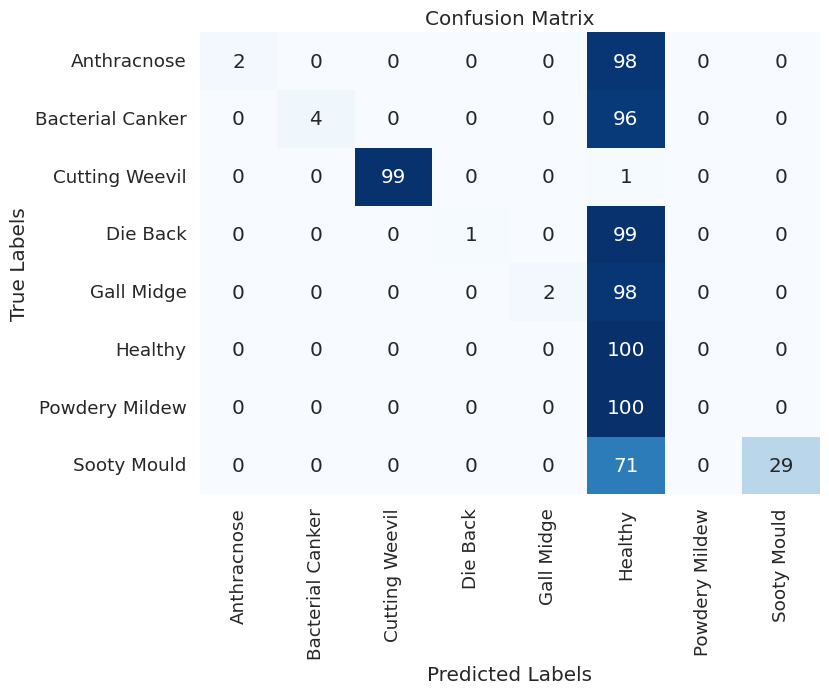

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#  learning rate = 0.025

In [20]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.025)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.5332 - loss: 210.3545 - val_accuracy: 0.7516 - val_loss: 2.4995
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.5799 - loss: 5.8625 - val_accuracy: 0.6984 - val_loss: 1.1807
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.5846 - loss: 1.9048 - val_accuracy: 0.7500 - val_loss: 1.3248
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.5552 - loss: 2.0636 - val_accuracy: 0.7312 - val_loss: 1.2412
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.5316 - loss: 2.5676 - val_accuracy: 0.6656 - val_loss: 1.0899
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5678 - loss: 2.3313 - val_accuracy: 0.6562 - val_loss: 1.3902
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.5108 - loss: 1.7089 - val_accuracy: 0.7531 - val_loss: 1.7223
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.5861 - loss: 1.1001 - val_accuracy: 0.

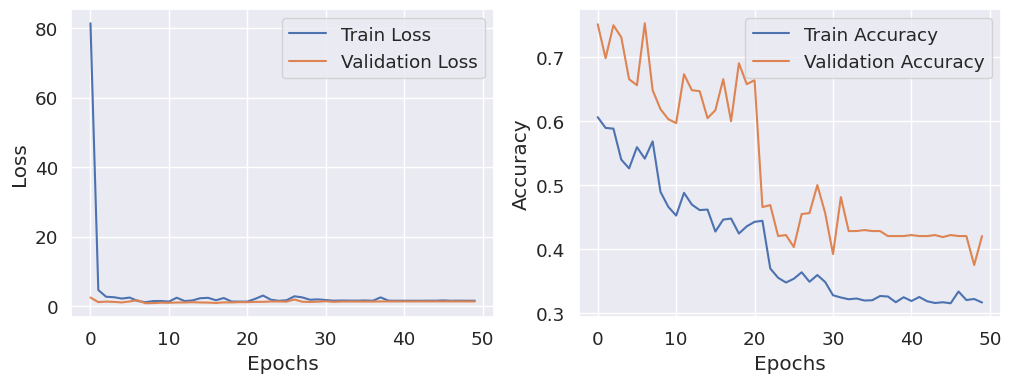

In [21]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.00      0.00      0.00       100
           2       0.99      0.99      0.99       100
           3       1.00      0.24      0.39       100
           4       1.00      0.10      0.18       100
           5       0.17      1.00      0.29       100
           6       1.00      0.13      0.23       100
           7       1.00      0.52      0.68       100

    accuracy                           0.37       800
   macro avg       0.64      0.37      0.34       800
weighted avg       0.64      0.37      0.34       800



In [23]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.3725


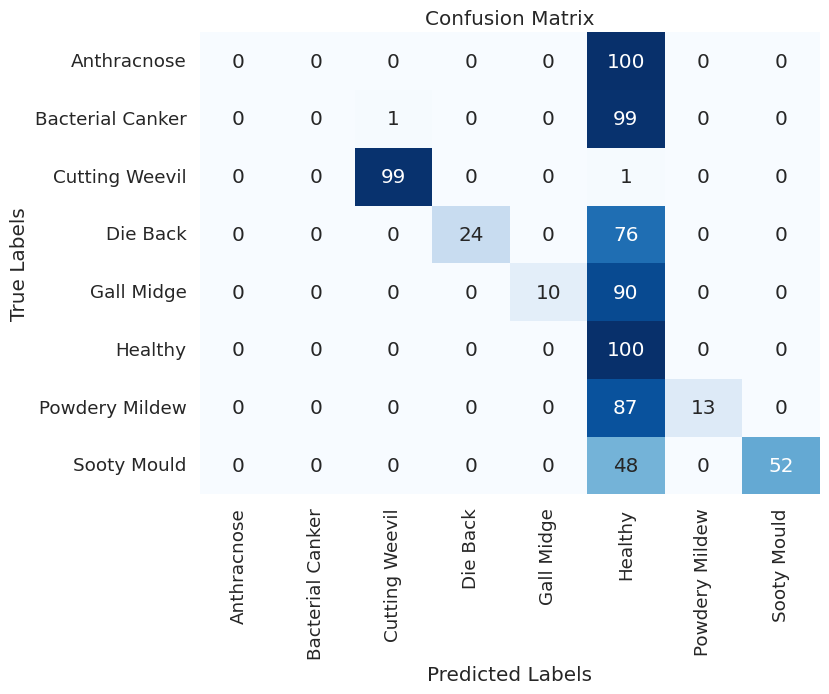

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Adam = 0.0100

In [25]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.0100)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.6154 - loss: 78.1611 - val_accuracy: 0.8625 - val_loss: 1.1771
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8094 - loss: 1.5133 - val_accuracy: 0.8422 - val_loss: 1.2811
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8027 - loss: 1.0894 - val_accuracy: 0.8313 - val_loss: 2.7810
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7841 - loss: 1.3339 - val_accuracy: 0.7891 - val_loss: 1.4205
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.7654 - loss: 1.1482 - val_accuracy: 0.8188 - val_loss: 1.5404
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7203 - loss: 1.7505 - val_accuracy: 0.8453 - val_loss: 0.8795
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.7529 - loss: 1.3997 - val_accuracy: 0.7969 - val_loss: 0.9924
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.7482 - loss: 1.2486 - val_accuracy: 0.8141

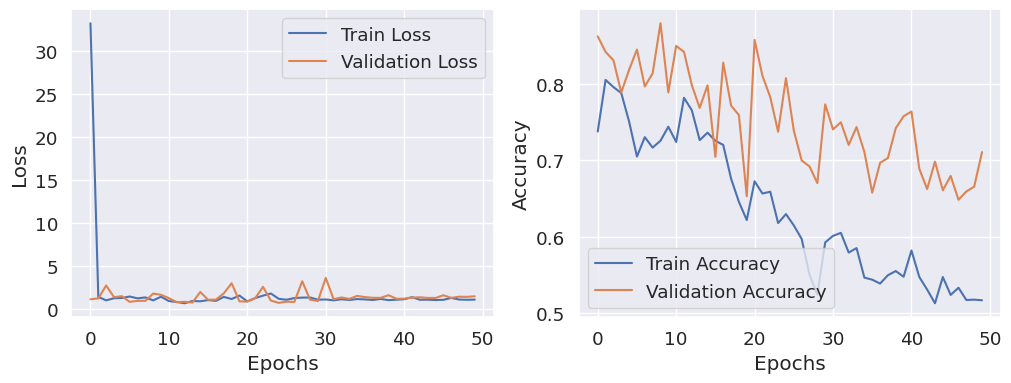

In [26]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.11      0.20       100
           1       1.00      0.86      0.92       100
           2       1.00      1.00      1.00       100
           3       0.98      1.00      0.99       100
           4       0.29      1.00      0.45       100
           5       0.96      0.89      0.92       100
           6       0.92      0.11      0.20       100
           7       1.00      0.48      0.65       100

    accuracy                           0.68       800
   macro avg       0.89      0.68      0.67       800
weighted avg       0.89      0.68      0.67       800



In [28]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.68125


In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.11      0.20       100
           1       1.00      0.86      0.92       100
           2       1.00      1.00      1.00       100
           3       0.98      1.00      0.99       100
           4       0.29      1.00      0.45       100
           5       0.96      0.89      0.92       100
           6       0.92      0.11      0.20       100
           7       1.00      0.48      0.65       100

    accuracy                           0.68       800
   macro avg       0.89      0.68      0.67       800
weighted avg       0.89      0.68      0.67       800

